In [12]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy.fft import fft, fftfreq, ifft

In [4]:
ticker = 'AAPL'
data = yf.download(ticker, start="2023""-01-01", end="2026-01-01", auto_adjust=True) # Precio de cierre ajustado
df = pd.DataFrame(data)

# Colapso de Covid-19 cambia drásticamente la varianza, estudiar desde 2023.

[*********************100%***********************]  1 of 1 completed


In [5]:
# Retornos y Volatilidad
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Returns'].rolling(window=21).std() # Volatilidad móvil de 21 días
df.dropna(inplace=True)
print(df)

Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2023-02-02  148.302994  148.656971  145.697210  146.415023  118339000   
2023-02-03  151.921555  154.753495  145.362872  145.559531  154357300   
2023-02-06  149.197784  150.544931  148.263642  150.023777   69858300   
2023-02-07  152.069031  152.639353  148.125959  148.125959   83322600   
2023-02-08  149.384628  152.000240  148.647145  151.311925   64120100   
...                ...         ...         ...         ...        ...   
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600   
2025-12-26  272.893005  274.859353  272.353998  273.651606   21521800   
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200   
2025-12-30  272.573547  273.571693  271.775043  272.304059   22139600   
2025-12-31  271.355835  273.172467  271.246054  272

In [6]:
# Test ADF
print(f'Test ADF para Precios de cierre de ({ticker})')
p_value = adfuller(df['Close']) # Dickey-Fuller Aumentada
print(f'P-value: {p_value[1]:.4f}')

print(f'Test ADF para Retornos logarítmicos de ({ticker})')
p_value = adfuller(df['Returns']) # Dickey-Fuller Aumentada
print(f'P-value: {p_value[1]:.4f}') 

Test ADF para Precios de cierre de (AAPL)
P-value: 0.6952
Test ADF para Retornos logarítmicos de (AAPL)
P-value: 0.0000


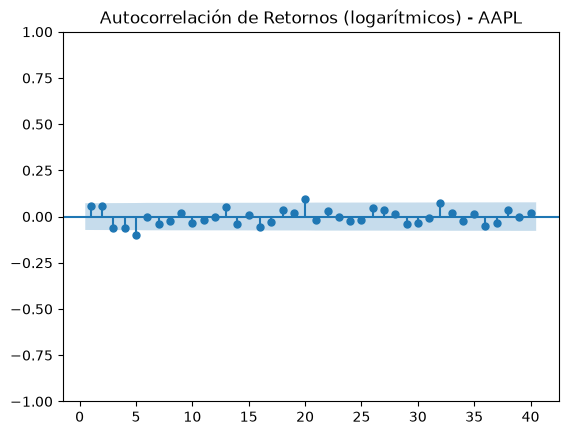

In [7]:
# Autocorrelación
plot_acf(df['Returns'], lags=40, zero=False)
plt.title(f"Autocorrelación de Retornos (logarítmicos) - {ticker}")
plt.show()

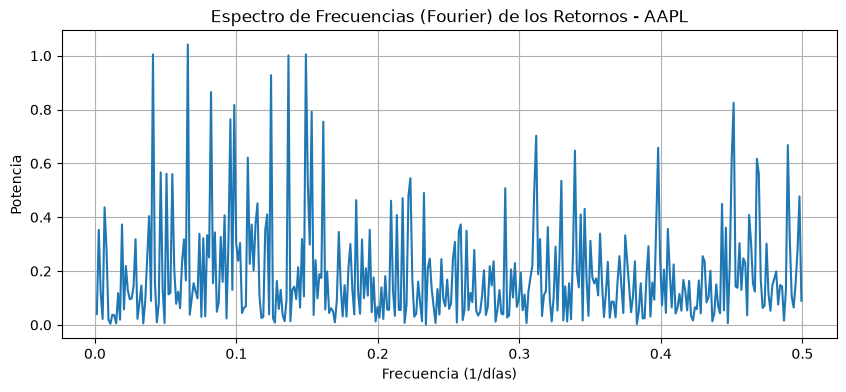

In [8]:
# Fourier (Expectro de Potencia)
# FFT sobre retornos para buscar periodicidades
N = len(df['Returns'])
returns_array = df['Returns'].values

yf_fft = fft(returns_array)
xf_freq = fftfreq(N, d=1) # 1 día de muestreo

pos_freq = xf_freq > 0 # 
frequencies = xf_freq[pos_freq]
power = np.abs(yf_fft[pos_freq]) ** 2 # Potenciar frecuencia

plt.figure(figsize=(10, 4))
plt.plot(frequencies, power)
plt.title(f"Espectro de Frecuencias (Fourier) de los Retornos - {ticker}")
plt.xlabel("Frecuencia (1/días)")
plt.ylabel("Potencia")
plt.grid(True)
plt.show()

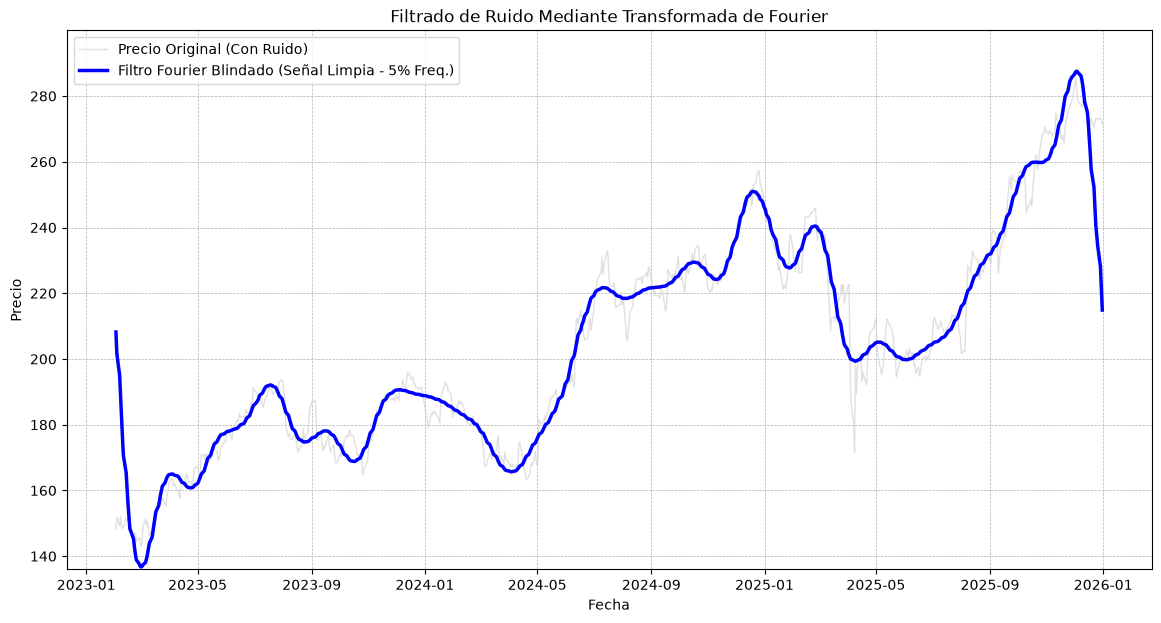

In [27]:
def filtro_fourier_precios_indestructible(serie_precios, porcentaje_frecuencias_a_mantener=0.05):
    serie_limpia = serie_precios.dropna()
    N = len(serie_limpia)
    senal_array = serie_limpia.values
    
    # FFT y frecuencias
    fft_senal = fft(senal_array)
    frecuencias = fftfreq(N)
    
    # Crear máscara 
    freq_absolutas = np.abs(frecuencias)
    umbral_freq = np.percentile(freq_absolutas, porcentaje_frecuencias_a_mantener * 100) # Límite exacto de frecuencia
    
    mascara = freq_absolutas <= umbral_freq # True para mantener, False para silenciar
    
    fft_filtrada = np.zeros_like(fft_senal) # Creamos el array de 0s y copiamos las tendencias de la mascara
    fft_filtrada[mascara] = fft_senal[mascara]
    
    # (IFFT)
    senal_reconstruida = np.real(ifft(fft_filtrada))
    serie_fourier = pd.Series(senal_reconstruida, index=serie_limpia.index)
    
    # Re-alinear con la serie original completa y rellenar nulos finales para que la gráfica sea continua.
    return serie_fourier.reindex(serie_precios.index).ffill().bfill()

# ==========================================
# APLICACIÓN Y VISUALIZACIÓN REVISADA
# ==========================================

df['Close_Clean'] = filtro_fourier_precios_indestructible(df['Close'].iloc[:, 0], porcentaje_frecuencias_a_mantener=0.05)

# Graficamos los resultados
plt.figure(figsize=(14, 7))

# Graficamos el original
plt.plot(df.index, df['Close'], label='Precio Original (Con Ruido)', color='lightgray', alpha=0.7, linewidth=1)

# Graficamos el nuevo filtro 
plt.plot(df.index, df['Close_Clean'], label='Filtro Fourier Blindado (Señal Limpia - 5% Freq.)', color='blue', linewidth=2.5)

plt.title("Filtrado de Ruido Mediante Transformada de Fourier")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.ylim(df['Close'].iloc[:, 0].min() * 0.95, df['Close'].iloc[:, 0].max() * 1.05) # .iloc[:, 0] para extraer los datos como un vector simple de números

plt.show()